In [2]:
import pandas as pd
seqtab_raw = pd.read_excel("seqtab_nochim_export.xlsx", index_col=0)

print(f"shape before transpose : {seqtab_raw.shape}  "
      f"({seqtab_raw.shape[0]} samples × {seqtab_raw.shape[1]} ASVs)")

seqtab = seqtab_raw.T

print(f"shape after  transpose : {seqtab.shape}  "
      f"({seqtab.shape[0]} ASVs × {seqtab.shape[1]} samples)")

seqtab.head()


shape before transpose : (59, 6693)  (59 samples × 6693 ASVs)
shape after  transpose : (6693, 59)  (6693 ASVs × 59 samples)


,CRC1,CRC10,CRC11,CRC12,CRC13,CRC14,CRC15,CRC16,CRC17,CRC18,...,Polype18,Polype19,Polype2,Polype3,Polype4,Polype5,Polype6,Polype7,Polype8,Polype9
CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGATACCCTGGTAGTC,34,58,176,0,0,20,0,53,0,0,...,0,39,55,121,0,125,0,0,0,65
CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGCGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCACCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGATGGGCAAGTCTGATGTGAAAACCCGGGGCTCAACCCCGGGACTGCATTGGAAACTGTTCATCTAGAGTGCTGGAGAGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACAGTAACTGACGTTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC,0,25,48,113,0,0,261,91,0,11,...,0,8,0,0,0,0,0,55,0,0
CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGATACCCGGGTAGTC,20,0,153,73,34,31,0,0,0,0,...,0,0,0,98,0,132,0,0,0,68
CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCAACGCCGCGTGAGTGATGACGGCCTTCGGGTTGTAAAGCTCTGTCTTCAGGGACGATAATGACGGTACCTGAGGAGGAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCGAGCGTTGTCCGGATTTACTGGGCGTAAAGGGAGCGTAGGCGGACTTTTAAGTGAGATGTGAAATACCCGGGCTCAACTTGGGTGCTGCATTTCAAACTGGAAGTCTAGAGTGCAGGAGAGGAGAATGGAATTCCTAGTGTAGCGGTGAAATGCGTAGAGATTAGGAAGAACACCAGTGGCGAAGGCGATTCTCTGGACTGTAACTGACGCTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC,0,0,0,0,0,0,0,90,0,0,...,0,0,0,265,0,479,0,0,0,285
CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGCGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGAAGAAATGACGGTACCTGACTAAGAAGCACCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGAAGGCTAAGTCTGATGTGAAAGCCCGGGGCTCAACCCCGGTACTGCATTGGAAACTGGTCATCTAGAGTGTCGGAGGGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACGATAACTGACGCTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC,76,0,40,49,69,33,56,16,21,0,...,0,0,35,0,46,0,0,50,0,0


In [3]:
df_taxa = pd.read_excel("taxa_species_export.xlsx", index_col=0)
df_taxa.index.name = "ASV_sequence"   

print(f"taxonomy table shape   : {df_taxa.shape}  "
      f"({df_taxa.shape[0]} ASVs × {df_taxa.shape[1]} taxonomic ranks)")

df_merged = seqtab.join(df_taxa, how="inner")

print(f"merged table shape     : {df_merged.shape}  "
      f"({df_merged.shape[0]} ASVs × {df_merged.shape[1]} columns "
      f"[{seqtab.shape[1]} samples + {df_taxa.shape[1]} taxonomic ranks])")


df_merged.head()


taxonomy table shape   : (6693, 7)  (6693 ASVs × 7 taxonomic ranks)
merged table shape     : (6693, 66)  (6693 ASVs × 66 columns [59 samples + 7 taxonomic ranks])


,CRC1,CRC10,CRC11,CRC12,CRC13,CRC14,CRC15,CRC16,CRC17,CRC18,...,Polype7,Polype8,Polype9,Kingdom,Phylum,Class,Order,Family,Genus,Species
CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGATACCCTGGTAGTC,34,58,176,0,0,20,0,53,0,0,...,0,0,65,Bacteria,Proteobacteria,Alphaproteobacteria,Rickettsiales,Mitochondria,NaN,NaN
CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGCGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCACCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGATGGGCAAGTCTGATGTGAAAACCCGGGGCTCAACCCCGGGACTGCATTGGAAACTGTTCATCTAGAGTGCTGGAGAGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACAGTAACTGACGTTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC,0,25,48,113,0,0,261,91,0,11,...,55,0,0,Bacteria,Firmicutes,Clostridia,Lachnospirales,Lachnospiraceae,[Ruminococcus] torques group,NaN
CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGATACCCGGGTAGTC,20,0,153,73,34,31,0,0,0,0,...,0,0,68,Bacteria,Proteobacteria,NaN,NaN,NaN,NaN,NaN
CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCAACGCCGCGTGAGTGATGACGGCCTTCGGGTTGTAAAGCTCTGTCTTCAGGGACGATAATGACGGTACCTGAGGAGGAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCGAGCGTTGTCCGGATTTACTGGGCGTAAAGGGAGCGTAGGCGGACTTTTAAGTGAGATGTGAAATACCCGGGCTCAACTTGGGTGCTGCATTTCAAACTGGAAGTCTAGAGTGCAGGAGAGGAGAATGGAATTCCTAGTGTAGCGGTGAAATGCGTAGAGATTAGGAAGAACACCAGTGGCGAAGGCGATTCTCTGGACTGTAACTGACGCTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC,0,0,0,0,0,0,0,90,0,0,...,0,0,285,Bacteria,Firmicutes,Clostridia,Clostridiales,Clostridiaceae,Clostridium sensu stricto 1,NaN
CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGCGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGAAGAAATGACGGTACCTGACTAAGAAGCACCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGAAGGCTAAGTCTGATGTGAAAGCCCGGGGCTCAACCCCGGTACTGCATTGGAAACTGGTCATCTAGAGTGTCGGAGGGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACGATAACTGACGCTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC,76,0,40,49,69,33,56,16,21,0,...,50,0,0,Bacteria,Firmicutes,Clostridia,Lachnospirales,Lachnospiraceae,Roseburia,inulinivorans


In [4]:
#aggregate asv
TAXONOMIC_RANKS = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]
df_merged["Genus"] = df_merged["Genus"].fillna(
    df_merged["Family"].astype(str) + "_unclassified"
)
count_cols = df_merged.columns.difference(TAXONOMIC_RANKS)
df_counts   = df_merged[count_cols]                  
genus_labels = df_merged["Genus"]                    

df_genus = (
    df_counts
    .groupby(genus_labels)
    .sum(numeric_only=True)   
)
df_genus.index.name = "Genus"

print(f"ASV-level shape  : {df_counts.shape}   ({df_counts.shape[0]} ASVs × {df_counts.shape[1]} samples)")
print(f"Genus-level shape: {df_genus.shape}  ({df_genus.shape[0]} genera × {df_genus.shape[1]} samples)")

df_genus.head()


ASV-level shape  : (6693, 59)   (6693 ASVs × 59 samples)
Genus-level shape: (247, 59)  (247 genera × 59 samples)


,CRC1,CRC10,CRC11,CRC12,CRC13,CRC14,CRC15,CRC16,CRC17,CRC18,...,Polype18,Polype19,Polype2,Polype3,Polype4,Polype5,Polype6,Polype7,Polype8,Polype9
Genus,,,,,,,,,,,,,,,,,,,,,
Acetanaerobacterium,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Actinomyces,0,0,29,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,19,10
Adlercreutzia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Agathobacter,250,168,69,490,61,86,193,546,25,914,...,156,277,0,0,0,0,127,356,0,0
Akkermansia,988,0,60,0,0,0,0,0,0,445,...,97,0,30,0,39,0,207,0,0,0


In [5]:
#joining genus tabble w metadata table
df_genus_T = df_genus.T
df_genus_T.index.name = "SampleID"

df_metadata = pd.read_csv("metadata.csv", sep=";", index_col="SampleID")
df_metadata_reindexed = df_metadata.reset_index().set_index("host_disease")
df_metadata_reindexed.index.name = "SampleID"

df_genus_T.index  = df_genus_T.index.astype(str).str.strip()
df_metadata_reindexed.index = df_metadata_reindexed.index.astype(str).str.strip()

df_ml_ready = df_genus_T.join(df_metadata_reindexed, how="inner")

df_ml_ready["host_disease"] = df_ml_ready.index

print(f"ML-ready table: {df_ml_ready.shape}  "
      f"({df_ml_ready.shape[0]} samples x {df_ml_ready.shape[1]} columns "
      f"[{df_genus_T.shape[1]} genus features + {df_metadata_reindexed.shape[1] + 1} metadata fields])")

df_ml_ready.head()


ML-ready table: (59, 253)  (59 samples x 253 columns [247 genus features + 6 metadata fields])


,Acetanaerobacterium,Actinomyces,Adlercreutzia,Agathobacter,Akkermansia,Alistipes,Allobaculum,Alloprevotella,Amaricoccus,Anaerococcus,...,[Ruminococcus] gnavus group,[Ruminococcus] torques group,possible genus Sk018,vadinBE97_unclassified,SampleID,SampleName,DiseaseStatus,Sex,Age,host_disease
SampleID,,,,,,,,,,,,,,,,,,,,,
CRC1,0,0,0,250,988,0,0,0,0,0,...,0,328,0,0,SRR29923448,CT8,Colorectal cancer,male,76,CRC1
CRC10,0,0,0,168,0,0,0,0,0,0,...,0,465,0,0,SRR29923474,CA11,Colorectal cancer,female,79,CRC10
CRC11,0,29,0,69,60,0,0,0,0,0,...,39,280,0,0,SRR29923475,CA12,Colorectal cancer,male,65,CRC11
CRC12,0,0,0,490,0,0,0,0,0,0,...,0,1890,0,0,SRR29923488,CA17,Colorectal cancer,female,42,CRC12
CRC13,0,0,0,61,0,0,0,0,0,0,...,0,1216,0,0,SRR29923489,CA18,Colorectal cancer,male,65,CRC13


In [6]:
#CLR eucleidean 
import numpy as np
from skbio.stats.composition import clr

METADATA_COLS = ["host_disease", "SampleName", "DiseaseStatus", "Sex", "Age", "SampleID"]
metadata_present = [c for c in METADATA_COLS if c in df_ml_ready.columns]

y = df_ml_ready["DiseaseStatus"]
X = df_ml_ready.drop(columns=metadata_present)

print(f"X shape: {X.shape}  |  y shape: {y.shape}")
print(f"         y labels: {y.unique().tolist()}")
prevalence_threshold = 0.10
prevalence = (X > 0).mean(axis=0)
mask = prevalence >= prevalence_threshold

n_removed = (~mask).sum()
X = X.loc[:, mask]

print(f"removed {n_removed} genus features  ->  X shape: {X.shape}")


X_pseudo = X + 1

print(f"Min value after pseudocount: {X_pseudo.values.min()}")


X_clr = pd.DataFrame(
    clr(X_pseudo.values),
    index=X_pseudo.index,
    columns=X_pseudo.columns
)

print(f"X_clr shape: {X_clr.shape}  |  "
      f"Value range: [{X_clr.values.min():.2f}, {X_clr.values.max():.2f}]")

X_clr.head()


X shape: (59, 247)  |  y shape: (59,)
         y labels: ['Colorectal cancer', 'Healthy', 'Adenomatous Polyps']
removed 137 genus features  ->  X shape: (59, 110)
Min value after pseudocount: 1
X_clr shape: (59, 110)  |  Value range: [-2.55, 8.65]


,Actinomyces,Agathobacter,Akkermansia,Alloprevotella,Anaerostipes,Anaerotruncus,Aquamonas,Atopobium,Bacteroides,Bifidobacterium,...,[Eubacterium] eligens group,[Eubacterium] hallii group,[Eubacterium] oxidoreducens group,[Eubacterium] ruminantium group,[Eubacterium] siraeum group,[Eubacterium] ventriosum group,[Eubacterium] xylanophilum group,[Ruminococcus] gauvreauii group,[Ruminococcus] gnavus group,[Ruminococcus] torques group
SampleID,,,,,,,,,,,,,,,,,,,,,
CRC1,-2.205458,3.319995,4.691236,-2.205458,1.921676,-2.205458,-2.205458,1.578731,-2.205458,-2.205458,...,2.138347,2.965026,-2.205458,-2.205458,-2.205458,-2.205458,0.502592,-2.205458,-2.205458,3.590600
CRC10,-1.627002,3.502897,-1.627002,-1.627002,-1.627002,-1.627002,1.591874,-1.627002,-1.627002,1.464041,...,1.899359,1.368731,-1.627002,-1.627002,-1.627002,-1.627002,-1.627002,2.827346,-1.627002,4.517184
CRC11,1.485401,2.332699,2.195078,-1.915796,1.028643,-1.915796,-1.915796,-1.915796,-1.915796,1.912845,...,-1.915796,-1.915796,-1.915796,1.175246,-1.915796,-1.915796,-1.915796,2.802703,1.773083,3.722559
CRC12,-2.470644,3.725800,-2.470644,-2.470644,-2.470644,0.362569,-2.470644,-2.470644,-0.861206,0.094305,...,1.518340,1.554707,-1.777497,1.672490,1.357997,-2.470644,-2.470644,-2.470644,-2.470644,5.074217
CRC13,-1.880116,2.247019,-1.880116,-1.880116,1.487180,-1.880116,-1.880116,-1.880116,-0.781504,3.182479,...,-1.880116,2.090176,-1.880116,-1.880116,-1.880116,-1.880116,-1.880116,2.011704,-1.880116,5.224028


In [7]:
#MRMR  + LASSO L1  + consensual biomarkers 
from mrmr import mrmr_classif
from sklearn.linear_model import LogisticRegression

mrmr_features = mrmr_classif(
    X=X_clr,
    y=y,
    K=15
)
print(f"\n mRMR selected {len(mrmr_features)} features:")
print(mrmr_features)
from sklearn.multiclass import OneVsRestClassifier

model_lasso = OneVsRestClassifier(
    LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000,
        random_state=42
    )
)
model_lasso.fit(X_clr, y)
coef_nonzero_mask = np.array([est.coef_[0] != 0 for est in model_lasso.estimators_]).any(axis=0)
lasso_features = X_clr.columns[coef_nonzero_mask].tolist()

print(f"\n LASSO selected {len(lasso_features)} features:")
print(lasso_features)
consensual_biomarkers = list(set(mrmr_features) & set(lasso_features))

print(f"\n Found {len(consensual_biomarkers)} consensual biomarkers:")
print(consensual_biomarkers)


100%|██████████| 15/15 [00:00<00:00, 38.56it/s]


 mRMR selected 15 features:
['Fusicatenibacter', 'Dorea', 'UCG-002', '[Ruminococcus] torques group', 'Lachnospira', 'Christensenellaceae R-7 group', 'Muribaculaceae_unclassified', 'Agathobacter', 'Anaerostipes', 'Lachnospiraceae UCG-010', 'Rothia', 'NK4A214 group', 'Lachnospiraceae_unclassified', '[Eubacterium] hallii group', 'Blautia']

 LASSO selected 49 features:
['Agathobacter', 'Akkermansia', 'Anaerostipes', 'Blautia', 'Butyricicoccus', 'Butyrivibrio', 'CAG-352', 'CAG-56', 'Campylobacter', 'Christensenellaceae R-7 group', 'Clostridium sensu stricto 1', 'Cutibacterium', 'Dorea', 'Eisenbergiella', 'Fournierella', 'Fusicatenibacter', 'Fusobacterium', 'GCA-900066575', 'Hungatella', 'Incertae Sedis', 'Lachnoclostridium', 'Lachnospira', 'Lachnospiraceae FCS020 group', 'Lachnospiraceae NK4A136 group', 'Lachnospiraceae UCG-010', 'Lachnospiraceae_unclassified', 'Marvinbryantia', 'Methanobrevibacter', 'Muribaculaceae_unclassified', 'NK4A214 group', 'Negativibacillus', 'Parvimonas', 'Peptos

In [8]:
#RF + SVM + CV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

X_final = X_clr[consensual_biomarkers]
y_target = y

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

svm_model = SVC(
    kernel='linear',
    probability=True,
    class_weight='balanced',
    random_state=42
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = ['accuracy', 'roc_auc_ovr', 'f1_macro']

rf_cv_results = cross_validate(rf_model, X_final, y_target, cv=cv_strategy, scoring=scoring_metrics)
svm_cv_results = cross_validate(svm_model, X_final, y_target, cv=cv_strategy, scoring=scoring_metrics)

def print_cv_results(model_name, cv_results):
    print(f" {model_name} Performance (5-Fold CV)")
    print(f"Accuracy : {np.mean(cv_results['test_accuracy']):.3f} ± {np.std(cv_results['test_accuracy']):.3f}")
    print(f"ROC-AUC  : {np.mean(cv_results['test_roc_auc_ovr']):.3f} ± {np.std(cv_results['test_roc_auc_ovr']):.3f}")
    print(f"F1-Macro : {np.mean(cv_results['test_f1_macro']):.3f} ± {np.std(cv_results['test_f1_macro']):.3f}\n")

print_cv_results("Random Forest", rf_cv_results)
print_cv_results("Support Vector Machine", svm_cv_results)

rf_final = rf_model.fit(X_final, y_target)
svm_final = svm_model.fit(X_final, y_target)


 Random Forest Performance (5-Fold CV)
Accuracy : 0.709 ± 0.178
ROC-AUC  : 0.828 ± 0.121
F1-Macro : 0.712 ± 0.173

 Support Vector Machine Performance (5-Fold CV)
Accuracy : 0.677 ± 0.171
ROC-AUC  : 0.840 ± 0.103
F1-Macro : 0.690 ± 0.160



Nested CV ROC-AUC (OVR): 0.802 ± 0.142

Highly stable biomarkers selected in 5/5 folds:
 - Akkermansia
 - Christensenellaceae R-7 group
 - Fusicatenibacter
 - Incertae Sedis
 - Lachnospira
 - Lachnospiraceae UCG-010
 - Lachnospiraceae_unclassified
 - NK4A214 group
 - Peptostreptococcus
 - Ruminococcus



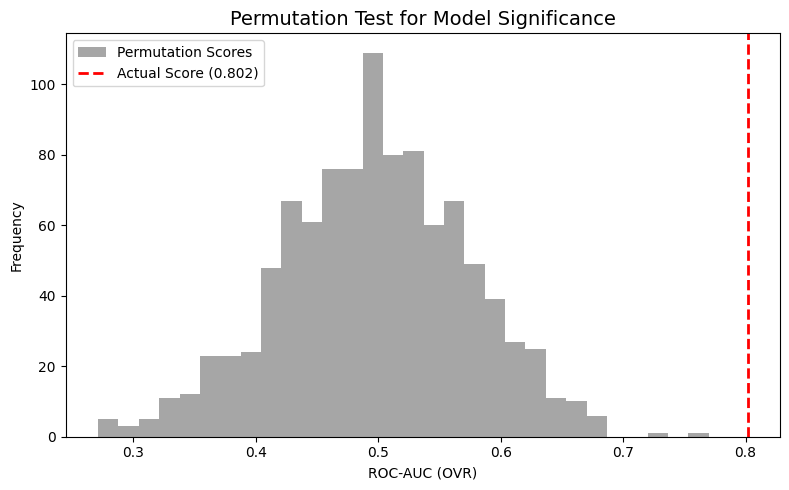

In [9]:
#Nested CV AUC + Permutation test n=1000
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, permutation_test_score
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

lasso_selector = SelectFromModel(
    LogisticRegression(penalty='l1', solver='saga', max_iter=2000, class_weight='balanced', random_state=42)
)

rf_classifier = RandomForestClassifier(
    max_depth=4, class_weight='balanced', random_state=42
)

pipeline = Pipeline([
    ('feature_selection', lasso_selector),
    ('classification', rf_classifier)
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X_clr, y_target, 
    cv=cv_strategy, 
    scoring='roc_auc_ovr'
)

print(f"Nested CV ROC-AUC (OVR): {np.mean(cv_results['test_score']):.3f} ± {np.std(cv_results['test_score']):.3f}\n")

feature_counter = Counter()

for train_idx, test_idx in cv_strategy.split(X_clr, y_target):
    X_train, y_train = X_clr.iloc[train_idx], y_target.iloc[train_idx]
    
    lasso_selector.fit(X_train, y_train)
    
    selected_mask = lasso_selector.get_support()
    selected_features = X_clr.columns[selected_mask]
    
    feature_counter.update(selected_features)

print("Highly stable biomarkers selected in 5/5 folds:")
stable_biomarkers = [feat for feat, count in feature_counter.items() if count == 5]
for feat in stable_biomarkers:
    print(f" - {feat}")
print()

score, permutation_scores, pvalue = permutation_test_score(
    pipeline, X_clr, y_target, 
    scoring="roc_auc_ovr", 
    cv=cv_strategy, 
    n_permutations=1000, 
    random_state=42,
    n_jobs=-1
)


plt.figure(figsize=(8, 5))
plt.hist(permutation_scores, bins=30, color='gray', alpha=0.7, label='Permutation Scores')
plt.axvline(score, color='red', linestyle='dashed', linewidth=2, label=f'Actual Score ({score:.3f})')
plt.title("Permutation Test for Model Significance", fontsize=14)
plt.xlabel("ROC-AUC (OVR)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

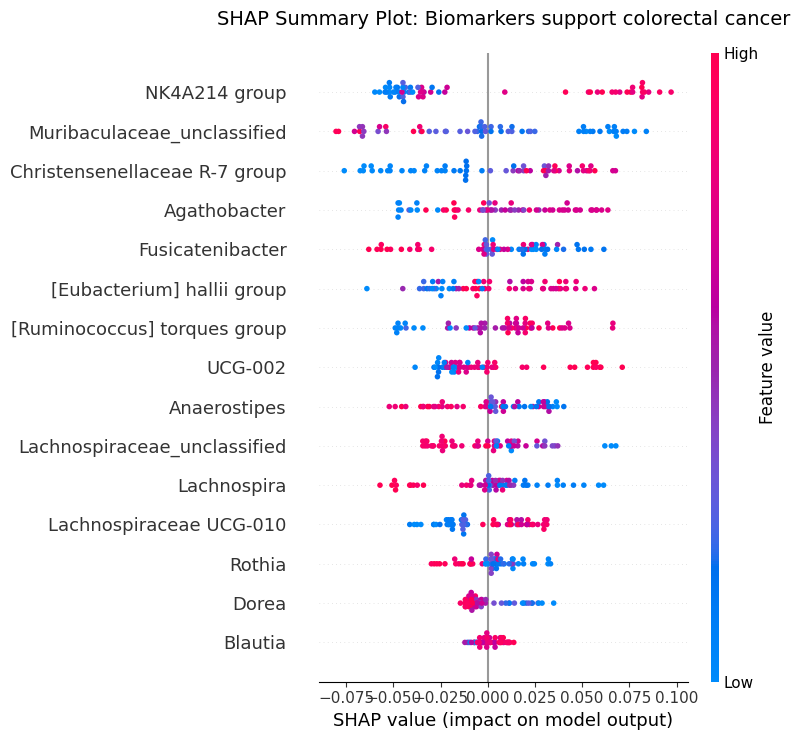

In [10]:
#SHAP 
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(rf_final)


shap_values = explainer.shap_values(X_final)

classes = [str(c).strip() for c in rf_final.classes_]
target_label = "Colorectal cancer"

try:
    crc_class_index = next(
        i for i, c in enumerate(classes)
        if c.casefold() == target_label.casefold()
    )
except StopIteration:
    raise ValueError(f"'{target_label}' is not in rf_final.classes_: {classes}")

if isinstance(shap_values, list):
    shap_values_crc = shap_values[crc_class_index]
else:
    shap_values_crc = shap_values[:, :, crc_class_index]
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Biomarkers support colorectal cancer", fontsize=14, pad=20)

shap.summary_plot(
    shap_values_crc, 
    X_final, 
    plot_type="dot", 
    show=False  # Giữ show=False để có thể tùy chỉnh thêm bằng matplotlib nếu cần
)

plt.tight_layout()
plt.show()


In [15]:
#LIME
import lime
import lime.lime_tabular
from IPython.display import HTML


lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_final.values,
    feature_names=X_final.columns.tolist(),
    class_names=rf_final.classes_,
    mode='classification',
    random_state=42
)
patient_idx = 'CRC1' #demo patient CRC1 - change the value for other patients

patient_data = X_final.loc[patient_idx].values


print(f"patient explain: {patient_idx}")
print(f"label: {y_target.loc[patient_idx]}")



lime_exp = lime_explainer.explain_instance(
    data_row=patient_data,
    predict_fn=rf_final.predict_proba,
    num_features=5,  
    top_labels=1     
)


HTML(lime_exp.as_html())


patient explain: CRC1
label: Colorectal cancer


In [12]:
import joblib
import os

os.makedirs('models', exist_ok=True)
model_path = 'models/rf_crc_model.pkl'
joblib.dump(rf_final, model_path)

print(f"models saved at: {model_path}")

joblib.dump(consensual_biomarkers, 'models/expected_features.pkl')

models saved at: models/rf_crc_model.pkl


['models/expected_features.pkl']